<a href="https://colab.research.google.com/github/Randivxxxx/NorthStar-Databases-Analytics/blob/main/Database.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "NorthStar_Full_Dataset.xlsx"

customers = pd.read_excel(file_path, sheet_name="customers")
orders = pd.read_excel(file_path, sheet_name="orders")
deliveries = pd.read_excel(file_path, sheet_name="deliveries")
drivers = pd.read_excel(file_path, sheet_name="drivers")
vehicles = pd.read_excel(file_path, sheet_name="vehicles")
hubs = pd.read_excel(file_path, sheet_name="hubs")
complaints = pd.read_excel(file_path, sheet_name="complaints")
incidents = pd.read_excel(file_path, sheet_name="incidents")
app_events = pd.read_excel(file_path, sheet_name="app_events")

deliveries.info()
deliveries.isnull().sum()

orders.info()
orders.isnull().sum()

complaints.info()
complaints.isnull().sum()

customers = customers.drop_duplicates()
orders = orders.drop_duplicates()
deliveries = deliveries.drop_duplicates()

customers.fillna("Unknown", inplace=True)
orders.fillna("Unknown", inplace=True)
deliveries.fillna("Unknown", inplace=True)
complaints.fillna("Unknown", inplace=True)

deliveries.columns = deliveries.columns.str.lower()
orders.columns = orders.columns.str.lower()
complaints.columns = complaints.columns.str.lower()

if 'order_date' in orders.columns:
    orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')


Saving NorthStar_Full_Dataset.xlsx to NorthStar_Full_Dataset.xlsx
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   delivery_id                    950 non-null    object 
 1   order_id                       950 non-null    object 
 2   driver_id                      950 non-null    object 
 3   vehicle_id                     950 non-null    object 
 4   hub_id                         950 non-null    object 
 5   dispatch_time                  950 non-null    object 
 6   delivery_completed_at          931 non-null    object 
 7   delivery_status                950 non-null    object 
 8   route_distance_km              950 non-null    float64
 9   manual_route_override_count    950 non-null    int64  
 10  proof_of_completion_missing    950 non-null    int64  
 11  customer_rating_post_delivery  936 non-null 

/tmp/ipykernel_1263/2293070666.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  customers.fillna("Unknown", inplace=True)
/tmp/ipykernel_1263/2293070666.py:35: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  deliveries.fillna("Unknown", inplace=True)
/tmp/ipykernel_1263/2293070666.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  complaints.fillna("Unknown", inplace=True)


In [4]:
deliveries.groupby('hub_id').size().sort_values(ascending=False)

,0
hub_id,
H01,136
H08,128
H04,127
H03,119
H07,115
H05,115
H02,106
H06,104


In [5]:
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'], errors='coerce')
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'], errors='coerce')

In [6]:
deliveries['delivery_time_minutes'] = (
    deliveries['delivery_completed_at'] - deliveries['dispatch_time']
).dt.total_seconds() / 60

In [7]:
deliveries['delivery_time_minutes'].isnull().sum()

np.int64(19)

In [8]:
deliveries_clean = deliveries.dropna(subset=['delivery_time_minutes'])

In [9]:
deliveries_clean.shape

(931, 14)

In [10]:
deliveries_clean['delivery_status'].value_counts()

,count
delivery_status,
OnTime,604
Delayed,198
Failed,129


In [11]:
deliveries_clean.groupby('hub_id')['delivery_time_minutes'].mean().sort_values(ascending=False)

,delivery_time_minutes
hub_id,
H05,654.248030
H04,619.829453
H07,595.113258
H08,589.150707
H01,562.902086
H06,562.758006
H02,532.024348
H03,459.414852


In [12]:
deliveries_clean.groupby('driver_id')['delivery_time_minutes'].mean().sort_values(ascending=False).head(10)

,delivery_time_minutes
driver_id,
D063,1303.750925
D062,1261.362154
D040,1124.622132
D023,1117.948473
D055,1109.522533
D057,1068.541632
D170,1035.455767
D001,1033.714714
D092,1018.190926


In [13]:
deliveries_clean.groupby('hub_id')['manual_route_override_count'].mean().sort_values(ascending=False)

,manual_route_override_count
hub_id,
H08,1.095238
H07,1.043860
H01,1.037594
H05,0.956140
H02,0.912621
H03,0.888889
H04,0.887097
H06,0.880000


In [14]:
deliveries_clean.groupby('hub_id')['fuel_or_charge_cost'].mean().sort_values(ascending=False)

,fuel_or_charge_cost
hub_id,
H05,13.744123
H06,13.364100
H04,13.226774
H07,12.941053
H01,12.784812
H03,12.781795
H02,12.543981
H08,11.688571


In [15]:
deliveries_clean['customer_rating_post_delivery'].describe()

,customer_rating_post_delivery
count,931.0
unique,284.0
top,5.0
freq,84.0


In [18]:
deliveries_analysis[['delivery_time_minutes',
                     'manual_route_override_count',
                     'fuel_or_charge_cost',
                     'customer_rating_post_delivery']].corr()

NameError: name 'deliveries_analysis' is not defined

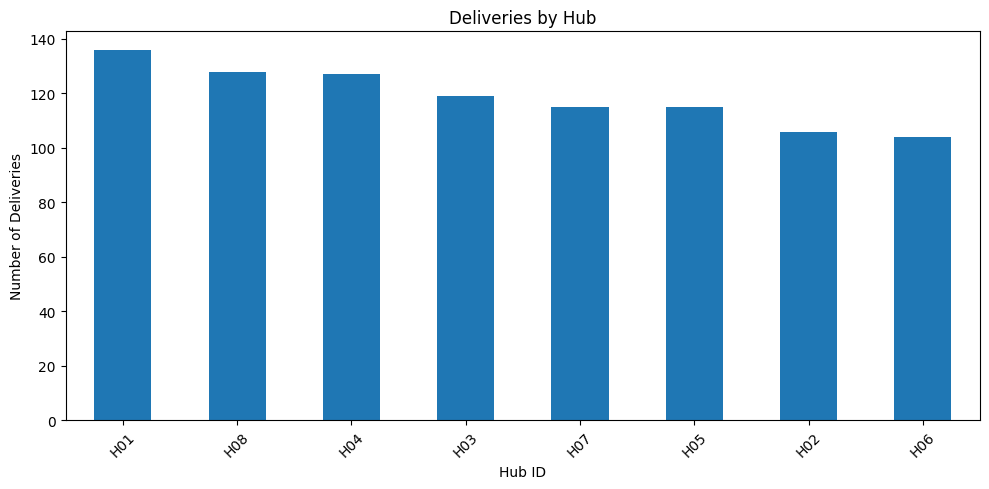

In [19]:
import matplotlib.pyplot as plt

hub_counts = deliveries.groupby('hub_id').size().sort_values(ascending=False)

plt.figure(figsize=(10,5))
hub_counts.plot(kind='bar')

plt.title("Deliveries by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

/tmp/ipykernel_1263/4027027113.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hub_counts, x='hub_id', y='deliveries', palette='Blues_r')


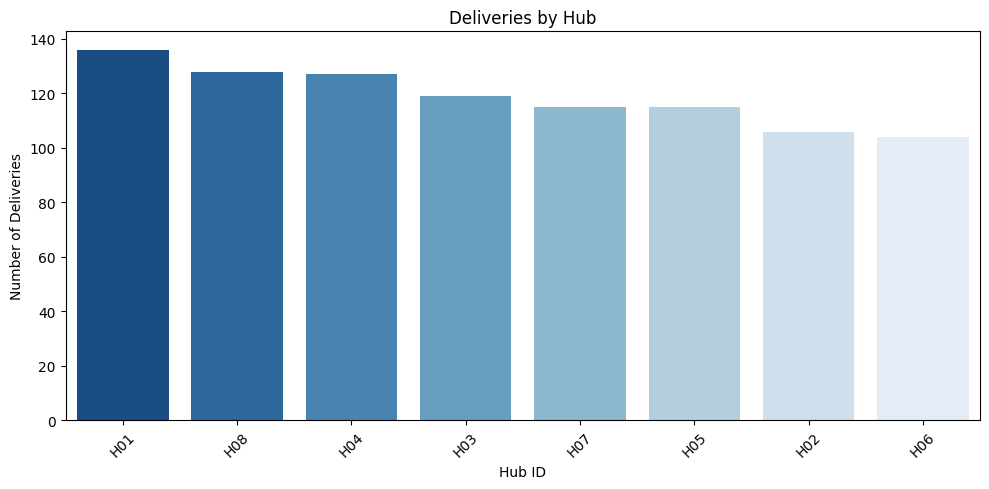

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare data
hub_counts = deliveries.groupby('hub_id').size().reset_index(name='deliveries')
hub_counts = hub_counts.sort_values(by='deliveries', ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=hub_counts, x='hub_id', y='deliveries', palette='Blues_r')

plt.title("Deliveries by Hub")
plt.xlabel("Hub ID")
plt.ylabel("Number of Deliveries")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()